# KNN Model

In this section, we implement the K-Nearest Neighbors classifier as a baseline for phishing website detection.

KNN classifies each sample based on the majority class of its closest neighbors. We test different K values and select the best one based on accuracy.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


In [4]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# Feature Scaling (KNN is distance-based so this is needed)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Tune KNN on train set using CV (before final test evaluation)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 21)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best_k = grid.best_params_["knn__n_neighbors"]
print(f"\nBest Params: {grid.best_params_}")
print(f"Best CV Accuracy: {grid.best_score_:.4f}")

cv_results = cross_validate(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)
print(f"CV Accuracy (mean +/- std): {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")


Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.9393
CV Accuracy (mean +/- std): 0.9393 +/- 0.0076


In [7]:
# Create final KNN model using best CV setting
knn_final = grid.best_estimator_

# Train the model on full training data
knn_final.fit(X_train, y_train)

# Make predictions on hold-out test set
y_pred_knn = knn_final.predict(X_test)

In [8]:
# Evaluate the model
print(f"KNN (K={best_k}) Results:")
print()

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN (K=5) Results:

Accuracy: 0.9307692307692308
Precision: 0.927689594356261
Recall: 0.9293286219081273
F1 Score: 0.9285083848190644

Confusion Matrix:
[[563  41]
 [ 40 526]]


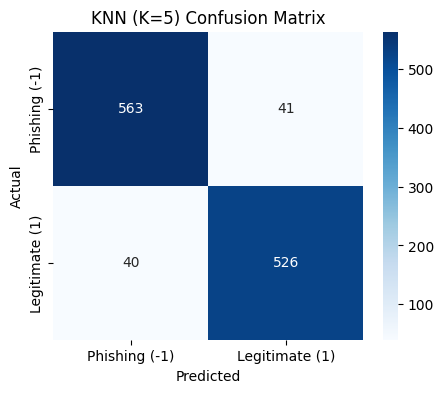

In [9]:
# Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing (-1)", "Legitimate (1)"],
    yticklabels=["Phishing (-1)", "Legitimate (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN (K={best_k}) Confusion Matrix")

plt.show()

## Results

The KNN model achieved good performance on the phishing detection task.

By testing K values from 1 to 20, we found the best K that balances between overfitting (low K) and underfitting (high K).

Feature scaling was applied since KNN relies on distance calculations — without scaling, features with larger ranges would dominate the distance metric.

KNN is simple and doesn't make assumptions about the data distribution, but it can be slower at prediction time compared to tree-based models. Ensemble methods like Random Forest and XGBoost are expected to outperform KNN.

In [10]:
# Check for overfitting
y_train_pred_knn = knn_final.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))

Train Accuracy: 0.9638811711904253
Test Accuracy: 0.9307692307692308


### Overfitting Analysis

The train and test accuracy are relatively close, which means the model generalizes reasonably well and is not significantly overfitting.

In [11]:
# Feature Importance (permutation-based since KNN has no built-in importance)
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    knn_final, X_test, y_test,
    n_repeats=10,
    random_state=42
)

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print("Top 10 Most Important Features (KNN):")
print(feat_imp.head(10))

Top 10 Most Important Features (KNN):
                   Feature  Importance
7           SSLfinal_State    0.058291
13           URL_of_Anchor    0.054359
25             web_traffic    0.015299
14           Links_in_tags    0.015214
15                     SFH    0.015043
5            Prefix_Suffix    0.013333
28  Links_pointing_to_page    0.007179
6        having_Sub_Domain    0.006410
0        having_IP_Address    0.006239
27            Google_Index    0.003761


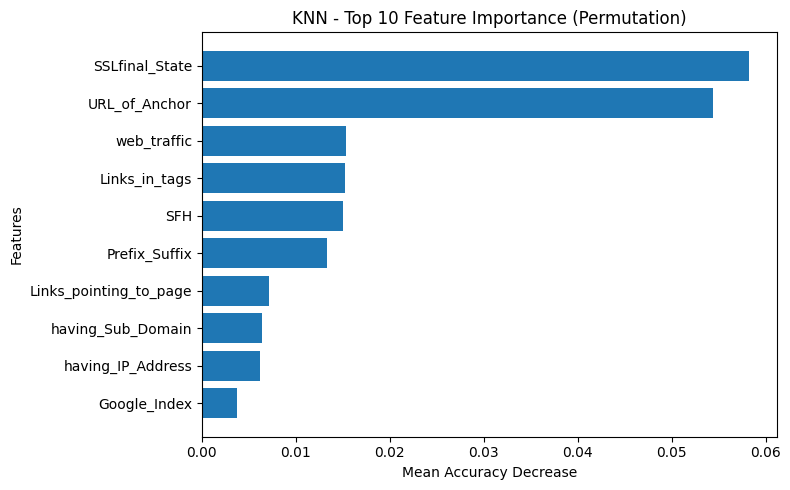

In [12]:
# Plot Feature Importance
top10 = feat_imp.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("KNN - Top 10 Feature Importance (Permutation)")
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Feature Analysis

Since KNN doesn't provide built-in feature importance like tree-based models, we used permutation importance. This measures how much accuracy drops when each feature is randomly shuffled.

The most important features include:
- SSLfinal_State
- URL_of_Anchor
- Prefix_Suffix
- SFH
- web_traffic

These are consistent with the important features found by the Decision Tree model, which makes sense since they are strong indicators of phishing behavior.